# Phase 2 — Préparation des données

## Projet : Healthy Illusion

L'objectif de ce notebook est de préparer le dataset pour la modélisation :

- vérifier et documenter le nettoyage ;
- traiter les valeurs manquantes ;
- vérifier les doublons et les incohérences ;
- analyser les outliers ;
- créer au moins 2 nouvelles variables dérivées justifiées métier ;
- préparer les variables numériques et catégorielles ;
- construire un pipeline de preprocessing reproductible et sérialisable ;
- effectuer une séparation train / validation / test stratifiée ;
- sauvegarder les fichiers traités dans `data/processed/` ;
- sauvegarder le preprocessor dans `models/preprocessor.joblib` ;
- préparer les stratégies de gestion du déséquilibre.

> Remarque : un premier nettoyage minimal a déjà été réalisé lors de la génération du dataset. Dans ce notebook, nous vérifions ce nettoyage, nous documentons les décisions et nous construisons le pipeline final de preprocessing pour la modélisation.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from pathlib import Path
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

## 1. Chargement du dataset

Le dataset utilisé est celui produit à la fin de la Phase 1 :

`data/dataset.csv`

In [3]:
PROJECT_ROOT = Path("..")

DATASET_PATH = PROJECT_ROOT / "data" / "dataset.csv"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(r"C:\Users\nouha\ML\Projet_ML_Healthy_illusion\data\dataset.csv")

df.head()

,code,product_name,brands,main_category,country,sugars_100g,fat_100g,saturated_fat_100g,salt_100g,fiber_100g,proteins_100g,energy_kcal_100g,additives_count,has_labels,image_saine,nutriscore_grade,bad_nutrition,healthy_illusion
0,8001420011593,Basmati integrale,Gallo,plant-based-foods-and-beverages,italy,0.8,2.7,0.8,0.00,2.8,8.8,353.0,0,0,1,b,0,0
1,3329770075405,Yop Parfum vanille,Yoplait,beverages-and-beverages-preparations,france,10.4,0.8,0.5,0.12,1.9,3.0,66.0,0,1,1,d,1,1
2,6130837000509,Couscous,NaN,plant-based-foods-and-beverages,france,3.0,2.0,0.3,0.01,1.9,12.0,354.0,0,0,1,a,0,0
3,3250390011958,YAOURT AU LAIT ENTIER POT VERRE 4X125G - nature,Pâturages,dairies,france,4.0,3.4,2.4,0.10,0.0,3.7,63.8,0,1,1,b,0,0
4,3368954600231,Ravioles du Dauphiné,"U Saveurs,U de nos Régions,U",plant-based-foods-and-beverages,france,2.2,11.0,7.1,1.60,2.4,14.0,282.0,0,1,1,d,1,1


In [4]:
print("Nombre de lignes :", df.shape[0])
print("Nombre de colonnes :", df.shape[1])

Nombre de lignes : 15114
Nombre de colonnes : 18


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15114 entries, 0 to 15113
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   code                15114 non-null  object 
 1   product_name        14840 non-null  str    
 2   brands              14710 non-null  str    
 3   main_category       15114 non-null  str    
 4   country             15114 non-null  str    
 5   sugars_100g         15114 non-null  float64
 6   fat_100g            15114 non-null  float64
 7   saturated_fat_100g  15114 non-null  float64
 8   salt_100g           15114 non-null  float64
 9   fiber_100g          15114 non-null  float64
 10  proteins_100g       15114 non-null  float64
 11  energy_kcal_100g    15114 non-null  float64
 12  additives_count     15114 non-null  int64  
 13  has_labels          15114 non-null  int64  
 14  image_saine         15114 non-null  int64  
 15  nutriscore_grade    15114 non-null  str    
 16  bad_nutrition  

## 2. Définition de la cible et des colonnes exclues

La variable cible du projet est :

`bad_nutrition`

Certaines colonnes ne doivent pas être utilisées comme variables d'entrée :

- `code` : identifiant du produit ;
- `product_name` : texte libre, non exploité dans cette version ;
- `brands` : forte cardinalité et risque de bruit ;
- `nutriscore_grade` : utilisé pour construire la cible, donc risque de data leakage ;
- `healthy_illusion` : dépend directement de `bad_nutrition`, donc risque de data leakage.

La variable `healthy_illusion` reste utile pour l'analyse métier, mais elle ne doit pas être donnée au modèle.

In [6]:
target = "bad_nutrition"

excluded_columns = [
    "code",
    "product_name",
    "brands",
    "nutriscore_grade",
    "healthy_illusion"
]

base_numeric_features = [
    "sugars_100g",
    "fat_100g",
    "saturated_fat_100g",
    "salt_100g",
    "fiber_100g",
    "proteins_100g",
    "energy_kcal_100g",
    "additives_count"
]

base_categorical_features = [
    "main_category",
    "country",
    "has_labels",
    "image_saine"
]

print("Target :", target)
print("Variables numériques initiales :", base_numeric_features)
print("Variables catégorielles initiales :", base_categorical_features)
print("Colonnes exclues :", excluded_columns)

Target : bad_nutrition
Variables numériques initiales : ['sugars_100g', 'fat_100g', 'saturated_fat_100g', 'salt_100g', 'fiber_100g', 'proteins_100g', 'energy_kcal_100g', 'additives_count']
Variables catégorielles initiales : ['main_category', 'country', 'has_labels', 'image_saine']
Colonnes exclues : ['code', 'product_name', 'brands', 'nutriscore_grade', 'healthy_illusion']


## 3. Vérification du nettoyage déjà réalisé

Le script de collecte a déjà appliqué un nettoyage minimal :

- suppression des produits sans Nutri-Score valide ;
- suppression des doublons selon `code` ;
- suppression des lignes ayant plus de 2 valeurs nutritionnelles manquantes ;
- imputation simple des valeurs nutritionnelles restantes par la médiane ;
- remplacement des catégories ou pays manquants par `unknown`.

Dans ce notebook, on vérifie l'état du dataset avant de construire le preprocessing final.

In [7]:
missing_table = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().sum() / len(df) * 100).round(2)
}).sort_values(by="missing_percent", ascending=False)

missing_table

,missing_count,missing_percent
brands,404,2.67
product_name,274,1.81
code,0,0.00
main_category,0,0.00
country,0,0.00
sugars_100g,0,0.00
fat_100g,0,0.00
saturated_fat_100g,0,0.00
salt_100g,0,0.00
fiber_100g,0,0.00


In [8]:
exact_duplicates = df.duplicated().sum()

print("Nombre de doublons exacts :", exact_duplicates)

if "code" in df.columns:
    code_duplicates = df["code"].duplicated().sum()
    print("Nombre de codes dupliqués :", code_duplicates)

Nombre de doublons exacts : 0
Nombre de codes dupliqués : 0


## 4. Vérification des incohérences métier

Pour les variables nutritionnelles, certaines valeurs ne doivent normalement pas être négatives.

On vérifie aussi les valeurs très élevées. Certaines peuvent correspondre à des erreurs de saisie dans la base Open Food Facts, mais d'autres peuvent être des valeurs réelles selon le type de produit.

In [9]:
incoherence_rows = []

for col in base_numeric_features:
    negative_count = (df[col] < 0).sum()
    max_value = df[col].max()
    
    incoherence_rows.append({
        "variable": col,
        "negative_values": int(negative_count),
        "min": df[col].min(),
        "max": max_value
    })

incoherence_table = pd.DataFrame(incoherence_rows)
incoherence_table

,variable,negative_values,min,max
0,sugars_100g,0,0.0,1.128571e+02
1,fat_100g,0,0.0,1.000000e+02
2,saturated_fat_100g,0,0.0,5.200000e+01
3,salt_100g,0,0.0,1.820000e+03
4,fiber_100g,0,0.0,6.111242e+12
5,proteins_100g,0,0.0,8.500000e+01
6,energy_kcal_100g,0,0.0,1.700000e+04
7,additives_count,0,0.0,1.400000e+01


### Décision

Les valeurs négatives sur les grandeurs nutritionnelles ne sont pas cohérentes.  
Si elles existent, elles seront remplacées par des valeurs manquantes, puis traitées par le pipeline d'imputation.

Les valeurs extrêmes positives seront analysées comme outliers. Elles ne seront pas supprimées automatiquement, car elles peuvent porter un signal utile pour détecter une mauvaise qualité nutritionnelle.

In [10]:
df_clean = df.copy()

for col in base_numeric_features:
    df_clean.loc[df_clean[col] < 0, col] = np.nan

df_clean[base_numeric_features].describe().T

,count,mean,std,min,25%,50%,75%,max
sugars_100g,15114.0,6.272528e+00,8.240303e+00,0.0,0.599449,3.5,9.556266,1.128571e+02
fat_100g,15114.0,4.845430e+00,9.015331e+00,0.0,0.500000,1.8,4.500000,1.000000e+02
saturated_fat_100g,15114.0,1.648855e+00,3.742626e+00,0.0,0.100000,0.4,1.700000,5.200000e+01
salt_100g,15114.0,6.102239e-01,1.713293e+01,0.0,0.010000,0.1,0.542375,1.820000e+03
fiber_100g,15114.0,4.043431e+08,4.970954e+10,0.0,0.800000,1.9,3.800000,6.111242e+12
proteins_100g,15114.0,6.780757e+00,6.628645e+00,0.0,1.600000,5.3,9.400000,8.500000e+01
energy_kcal_100g,15114.0,1.883505e+02,2.183904e+02,0.0,57.000000,110.0,350.000000,1.700000e+04
additives_count,15114.0,5.889242e-01,1.275179e+00,0.0,0.000000,0.0,1.000000,1.400000e+01


## 5. Analyse des outliers

Nous utilisons la méthode IQR :

- Q1 : premier quartile ;
- Q3 : troisième quartile ;
- IQR = Q3 - Q1 ;
- outlier si valeur < Q1 - 1.5 × IQR ou valeur > Q3 + 1.5 × IQR.

Dans ce projet, les outliers ne seront pas supprimés automatiquement.  
Ils peuvent représenter des produits réellement très sucrés, très gras, très salés ou très caloriques, donc potentiellement importants pour la prédiction.

In [11]:
outlier_summary = []

for col in base_numeric_features:
    q1 = df_clean[col].quantile(0.25)
    q3 = df_clean[col].quantile(0.75)
    iqr = q3 - q1
    
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    outliers = df_clean[(df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)]
    
    outlier_summary.append({
        "variable": col,
        "Q1": round(q1, 3),
        "Q3": round(q3, 3),
        "IQR": round(iqr, 3),
        "lower_bound": round(lower_bound, 3),
        "upper_bound": round(upper_bound, 3),
        "outlier_count": len(outliers),
        "outlier_percent": round(len(outliers) / len(df_clean) * 100, 2)
    })

outlier_table = pd.DataFrame(outlier_summary)
outlier_table

,variable,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count,outlier_percent
0,sugars_100g,0.599,9.556,8.957,-12.836,22.991,690,4.57
1,fat_100g,0.500,4.500,4.000,-5.500,10.500,2020,13.37
2,saturated_fat_100g,0.100,1.700,1.600,-2.300,4.100,1491,9.87
3,salt_100g,0.010,0.542,0.532,-0.789,1.341,794,5.25
4,fiber_100g,0.800,3.800,3.000,-3.700,8.300,1394,9.22
5,proteins_100g,1.600,9.400,7.800,-10.100,21.100,928,6.14
6,energy_kcal_100g,57.000,350.000,293.000,-382.500,789.500,50,0.33
7,additives_count,0.000,1.000,1.000,-1.500,2.500,1152,7.62


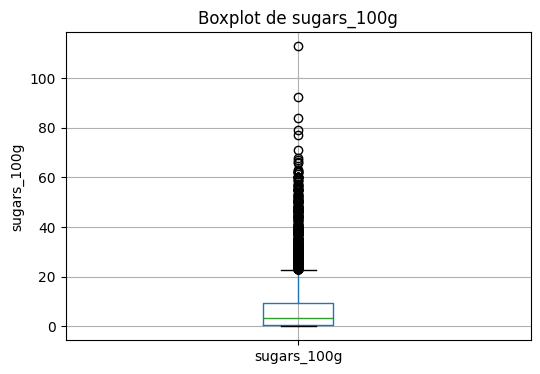

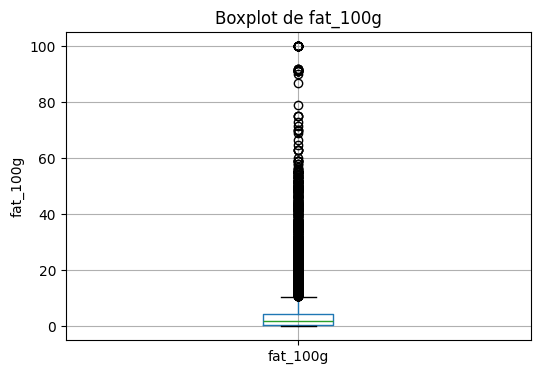

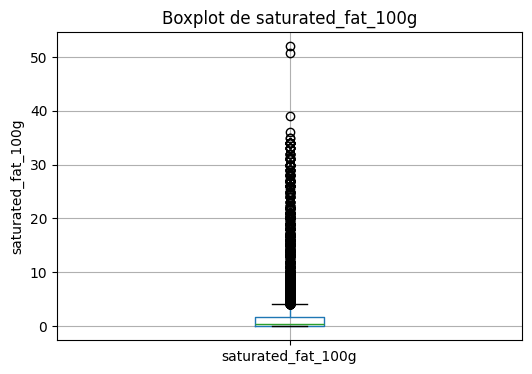

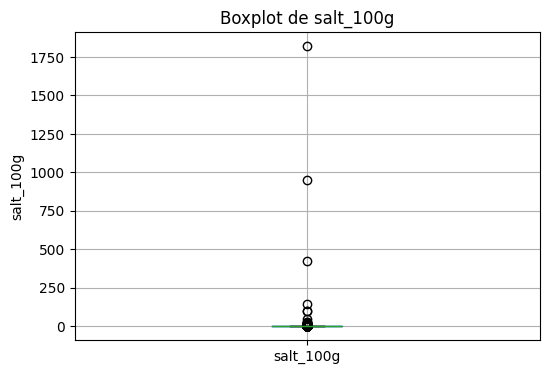

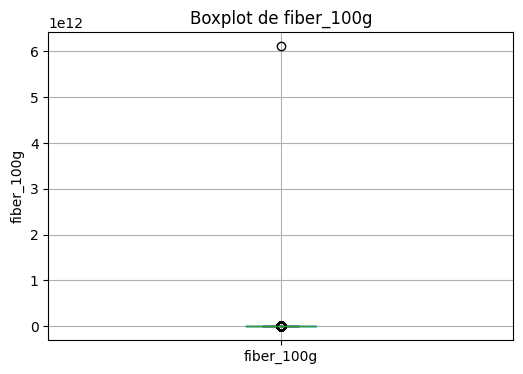

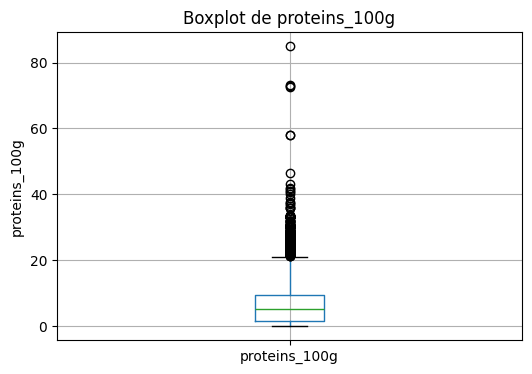

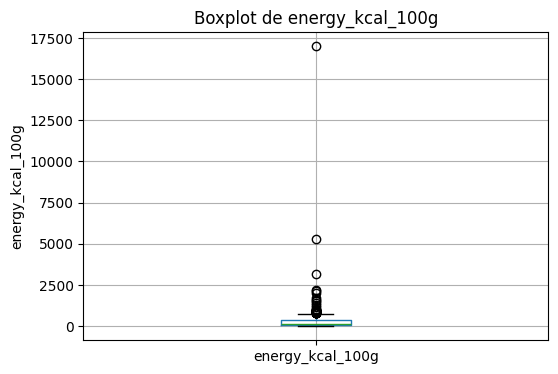

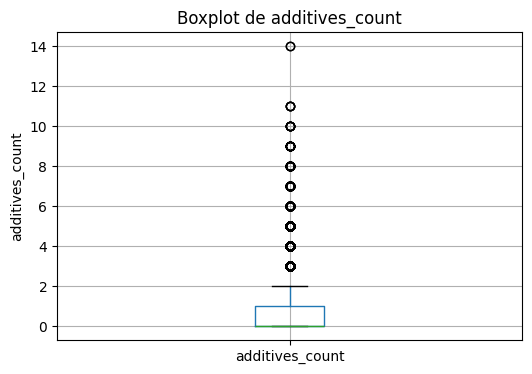

In [12]:
for col in base_numeric_features:
    plt.figure(figsize=(6, 4))
    df_clean.boxplot(column=col)
    plt.title(f"Boxplot de {col}")
    plt.ylabel(col)
    plt.show()

### Décision sur les outliers

Les outliers sont conservés.

Justification métier : dans le contexte alimentaire, une valeur élevée en sucre, sel, graisses ou énergie peut être un signal fort de mauvaise qualité nutritionnelle.  
Les supprimer risquerait donc de retirer des informations utiles pour la classe minoritaire `bad_nutrition = 1`.

## 6. Feature engineering

Nous allons créer 4 nouvelles variables :

1. `sugar_energy_ratio` : rapport entre les sucres et l'énergie ;
2. `sat_fat_ratio` : part des graisses saturées dans les graisses totales ;
3. `salt_sugar_interaction` : interaction entre le sel et le sucre ;
4. `nutrition_risk_score` : score simple combinant sucre, graisses saturées, sel, énergie et faible présence de fibres.

Ces variables ne dépendent pas de la cible. Elles peuvent donc être créées avant la séparation train / validation / test.

In [13]:
def add_engineered_features(data: pd.DataFrame) -> pd.DataFrame:
    data = data.copy()
    
    epsilon = 1e-6
    
    data["sugar_energy_ratio"] = data["sugars_100g"] / (data["energy_kcal_100g"] + epsilon)
    data["sat_fat_ratio"] = data["saturated_fat_100g"] / (data["fat_100g"] + epsilon)
    data["salt_sugar_interaction"] = data["salt_100g"] * data["sugars_100g"]
    
    data["nutrition_risk_score"] = (
        data["sugars_100g"]
        + data["saturated_fat_100g"]
        + data["salt_100g"] * 10
        + data["energy_kcal_100g"] / 100
        - data["fiber_100g"]
    )
    
    engineered_cols = [
        "sugar_energy_ratio",
        "sat_fat_ratio",
        "salt_sugar_interaction",
        "nutrition_risk_score"
    ]
    
    data[engineered_cols] = data[engineered_cols].replace([np.inf, -np.inf], np.nan)
    
    return data

df_fe = add_engineered_features(df_clean)

df_fe.head()

,code,product_name,brands,main_category,country,sugars_100g,fat_100g,saturated_fat_100g,salt_100g,fiber_100g,...,additives_count,has_labels,image_saine,nutriscore_grade,bad_nutrition,healthy_illusion,sugar_energy_ratio,sat_fat_ratio,salt_sugar_interaction,nutrition_risk_score
0,8001420011593,Basmati integrale,Gallo,plant-based-foods-and-beverages,italy,0.8,2.7,0.8,0.00,2.8,...,0.0,0,1,b,0,0,0.002266,0.296296,0.000,2.330
1,3329770075405,Yop Parfum vanille,Yoplait,beverages-and-beverages-preparations,france,10.4,0.8,0.5,0.12,1.9,...,0.0,1,1,d,1,1,0.157576,0.624999,1.248,10.860
2,6130837000509,Couscous,NaN,plant-based-foods-and-beverages,france,3.0,2.0,0.3,0.01,1.9,...,0.0,0,1,a,0,0,0.008475,0.150000,0.030,5.040
3,3250390011958,YAOURT AU LAIT ENTIER POT VERRE 4X125G - nature,Pâturages,dairies,france,4.0,3.4,2.4,0.10,0.0,...,0.0,1,1,b,0,0,0.062696,0.705882,0.400,8.038
4,3368954600231,Ravioles du Dauphiné,"U Saveurs,U de nos Régions,U",plant-based-foods-and-beverages,france,2.2,11.0,7.1,1.60,2.4,...,0.0,1,1,d,1,1,0.007801,0.645454,3.520,25.720


In [14]:
engineered_features = [
    "sugar_energy_ratio",
    "sat_fat_ratio",
    "salt_sugar_interaction",
    "nutrition_risk_score"
]

df_fe[engineered_features].describe().T

,count,mean,std,min,25%,50%,75%,max
sugar_energy_ratio,15114.0,5.551206e+03,2.935424e+05,0.000000e+00,0.003318,0.031042,0.097021,3.400000e+07
sat_fat_ratio,15114.0,2.999746e+03,5.925371e+04,0.000000e+00,0.111111,0.200000,0.483871,6.133333e+06
salt_sugar_interaction,15114.0,8.420596e+00,4.917503e+02,0.000000e+00,0.002000,0.310000,1.400000,5.514600e+04
nutrition_risk_score,15114.0,-4.043431e+08,4.970954e+10,-6.111242e+12,2.700313,7.465833,14.350000,1.823076e+04


## 7. Sélection finale des variables

Les variables utilisées pour la modélisation sont :

- les variables nutritionnelles numériques ;
- les variables dérivées créées par feature engineering ;
- les variables catégorielles utiles : catégorie, pays, présence de labels et image saine.

Les colonnes responsables de data leakage restent exclues.

In [15]:
numeric_features = base_numeric_features + engineered_features
categorical_features = base_categorical_features

feature_columns = numeric_features + categorical_features

X = df_fe[feature_columns].copy()
y = df_fe[target].copy()

print("Nombre total de features avant encodage :", len(feature_columns))
print("Variables numériques :", numeric_features)
print("Variables catégorielles :", categorical_features)

X.head()

Nombre total de features avant encodage : 16
Variables numériques : ['sugars_100g', 'fat_100g', 'saturated_fat_100g', 'salt_100g', 'fiber_100g', 'proteins_100g', 'energy_kcal_100g', 'additives_count', 'sugar_energy_ratio', 'sat_fat_ratio', 'salt_sugar_interaction', 'nutrition_risk_score']
Variables catégorielles : ['main_category', 'country', 'has_labels', 'image_saine']


,sugars_100g,fat_100g,saturated_fat_100g,salt_100g,fiber_100g,proteins_100g,energy_kcal_100g,additives_count,sugar_energy_ratio,sat_fat_ratio,salt_sugar_interaction,nutrition_risk_score,main_category,country,has_labels,image_saine
0,0.8,2.7,0.8,0.00,2.8,8.8,353.0,0.0,0.002266,0.296296,0.000,2.330,plant-based-foods-and-beverages,italy,0,1
1,10.4,0.8,0.5,0.12,1.9,3.0,66.0,0.0,0.157576,0.624999,1.248,10.860,beverages-and-beverages-preparations,france,1,1
2,3.0,2.0,0.3,0.01,1.9,12.0,354.0,0.0,0.008475,0.150000,0.030,5.040,plant-based-foods-and-beverages,france,0,1
3,4.0,3.4,2.4,0.10,0.0,3.7,63.8,0.0,0.062696,0.705882,0.400,8.038,dairies,france,1,1
4,2.2,11.0,7.1,1.60,2.4,14.0,282.0,0.0,0.007801,0.645454,3.520,25.720,plant-based-foods-and-beverages,france,1,1


In [16]:
y.value_counts(normalize=True).mul(100).round(2)

bad_nutrition
0    82.49
1    17.51
Name: proportion, dtype: float64

## 8. Séparation train / validation / test stratifiée

La séparation est faite de manière stratifiée sur la cible `bad_nutrition`.

Proportion choisie :

- 60 % train ;
- 20 % validation ;
- 20 % test.

In [17]:
RANDOM_STATE = 42

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.40,
    random_state=RANDOM_STATE,
    stratify=y
)

X_validation, X_test, y_validation, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

print("Train :", X_train.shape, y_train.shape)
print("Validation :", X_validation.shape, y_validation.shape)
print("Test :", X_test.shape, y_test.shape)

Train : (9068, 16) (9068,)
Validation : (3023, 16) (3023,)
Test : (3023, 16) (3023,)


In [18]:
split_distribution = pd.DataFrame({
    "train_percent": y_train.value_counts(normalize=True).sort_index() * 100,
    "validation_percent": y_validation.value_counts(normalize=True).sort_index() * 100,
    "test_percent": y_test.value_counts(normalize=True).sort_index() * 100
}).round(2)

split_distribution

,train_percent,validation_percent,test_percent
bad_nutrition,,,
0,82.49,82.47,82.5
1,17.51,17.53,17.5


La distribution de la cible est conservée dans les trois sous-ensembles grâce à `stratify=y`.

## 9. Sauvegarde des datasets traités

Les fichiers seront sauvegardés dans :

`data/processed/`

Chaque fichier contient les features sélectionnées et la cible.

In [19]:
train_df = X_train.copy()
train_df[target] = y_train.values

validation_df = X_validation.copy()
validation_df[target] = y_validation.values

test_df = X_test.copy()
test_df[target] = y_test.values

train_path = PROCESSED_DIR / "train.csv"
validation_path = PROCESSED_DIR / "validation.csv"
test_path = PROCESSED_DIR / "test.csv"

train_df.to_csv(train_path, index=False, encoding="utf-8")
validation_df.to_csv(validation_path, index=False, encoding="utf-8")
test_df.to_csv(test_path, index=False, encoding="utf-8")

print("Fichiers sauvegardés :")
print(train_path)
print(validation_path)
print(test_path)

Fichiers sauvegardés :
..\data\processed\train.csv
..\data\processed\validation.csv
..\data\processed\test.csv


## 10. Construction du pipeline de preprocessing

Le pipeline doit être reproductible et sérialisable.

Structure utilisée :

- Sous-pipeline numérique :
  - imputation par la médiane ;
  - `StandardScaler` pour préparer les modèles sensibles à l'échelle.

- Sous-pipeline catégoriel :
  - imputation par la modalité la plus fréquente ;
  - One-Hot Encoding avec gestion des modalités inconnues.

Le pipeline est entraîné uniquement sur `X_train`, afin d'éviter le data leakage.

In [20]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_features),
        ("categorical", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_na

In [21]:
preprocessor.fit(X_train)

X_train_preprocessed = preprocessor.transform(X_train)
X_validation_preprocessed = preprocessor.transform(X_validation)
X_test_preprocessed = preprocessor.transform(X_test)

print("Shape train après preprocessing :", X_train_preprocessed.shape)
print("Shape validation après preprocessing :", X_validation_preprocessed.shape)
print("Shape test après preprocessing :", X_test_preprocessed.shape)

Shape train après preprocessing : (9068, 120)
Shape validation après preprocessing : (3023, 120)
Shape test après preprocessing : (3023, 120)


## 11. Sérialisation du pipeline

Le preprocessor est sauvegardé dans :

`models/preprocessor.joblib`

In [22]:
preprocessor_path = MODELS_DIR / "preprocessor.joblib"

joblib.dump(preprocessor, preprocessor_path)

print("Pipeline de preprocessing sauvegardé dans :", preprocessor_path)

Pipeline de preprocessing sauvegardé dans : ..\models\preprocessor.joblib


## 12. Préparation des stratégies de gestion du déséquilibre

Dans cette phase on ne va pas entraîner les modèles, mais il faut que nous préparons les stratégies de gestion du déséquilibre.

Nous allons prévoir au minimum 3 stratégies :

1. Aucun rééquilibrage direct, mais utilisation de `class_weight='balanced'` pour les modèles compatibles ;
2. Oversampling de la classe minoritaire avec SMOTE ;
3. Undersampling de la classe majoritaire avec RandomUnderSampler.

In [26]:
try:
    from imblearn.over_sampling import SMOTE, RandomOverSampler
    from imblearn.under_sampling import RandomUnderSampler
    from imblearn.pipeline import Pipeline as ImbPipeline
    
    imbalance_strategies = {
        "baseline_class_weight_balanced": None,
        "smote": SMOTE(random_state=RANDOM_STATE),
        "random_oversampling": RandomOverSampler(random_state=RANDOM_STATE),
        "random_undersampling": RandomUnderSampler(random_state=RANDOM_STATE)
    }
    
    print("Stratégies de déséquilibre préparées :")
    for name in imbalance_strategies:
        print("-", name)

except ImportError:
    print("La librairie imbalanced-learn n'est pas installée.")
    print("Installation possible : pip install imbalanced-learn")

Stratégies de déséquilibre préparées :
- baseline_class_weight_balanced
- smote
- random_oversampling
- random_undersampling


## 13. Tableau des décisions de preprocessing

In [24]:
decisions = [
    {
        "Variable": "code",
        "Action effectuée": "Suppression de la modélisation",
        "Type d'action": "Suppression",
        "Justification": "Identifiant unique du produit. Il ne contient pas d'information généralisable pour prédire la qualité nutritionnelle."
    },
    {
        "Variable": "product_name",
        "Action effectuée": "Suppression de la modélisation",
        "Type d'action": "Suppression",
        "Justification": "Texte libre avec beaucoup de modalités différentes. Non exploité dans cette version du projet afin de garder un modèle tabulaire simple."
    },
    {
        "Variable": "brands",
        "Action effectuée": "Suppression de la modélisation",
        "Type d'action": "Suppression",
        "Justification": "Variable avec forte cardinalité. Son encodage créerait beaucoup de colonnes et pourrait introduire du bruit."
    },
    {
        "Variable": "nutriscore_grade",
        "Action effectuée": "Suppression de la modélisation",
        "Type d'action": "Suppression",
        "Justification": "Cette variable sert à construire la cible bad_nutrition. L'utiliser comme feature créerait un data leakage."
    },
    {
        "Variable": "healthy_illusion",
        "Action effectuée": "Suppression de la modélisation",
        "Type d'action": "Suppression",
        "Justification": "Variable construite à partir de image_saine et bad_nutrition. Elle dépend donc directement de la cible et ne doit pas être utilisée comme entrée du modèle."
    },

    {
        "Variable": "sugars_100g",
        "Action effectuée": "Imputation médiane + normalisation",
        "Type d'action": "Imputation + transformation",
        "Justification": "Variable numérique nutritionnelle. Les valeurs manquantes sont imputées par la médiane calculée sur le train set, puis la variable est standardisée pour les modèles sensibles à l'échelle."
    },
    {
        "Variable": "fat_100g",
        "Action effectuée": "Imputation médiane + normalisation",
        "Type d'action": "Imputation + transformation",
        "Justification": "Variable numérique positive. L'imputation médiane est robuste aux valeurs extrêmes, puis StandardScaler permet d'avoir une échelle comparable avec les autres variables numériques."
    },
    {
        "Variable": "saturated_fat_100g",
        "Action effectuée": "Imputation médiane + normalisation",
        "Type d'action": "Imputation + transformation",
        "Justification": "Variable importante pour la qualité nutritionnelle. Elle est imputée par la médiane et standardisée avant la modélisation."
    },
    {
        "Variable": "salt_100g",
        "Action effectuée": "Imputation médiane + normalisation",
        "Type d'action": "Imputation + transformation",
        "Justification": "Variable numérique liée au risque nutritionnel. Les valeurs manquantes sont imputées par la médiane et la variable est standardisée."
    },
    {
        "Variable": "fiber_100g",
        "Action effectuée": "Imputation médiane + normalisation",
        "Type d'action": "Imputation + transformation",
        "Justification": "Variable numérique utile car les fibres peuvent indiquer une meilleure qualité nutritionnelle. Elle est imputée par la médiane puis standardisée."
    },
    {
        "Variable": "proteins_100g",
        "Action effectuée": "Imputation médiane + normalisation",
        "Type d'action": "Imputation + transformation",
        "Justification": "Variable nutritionnelle numérique. L'imputation médiane limite l'influence des valeurs extrêmes et la normalisation prépare les modèles sensibles à l'échelle."
    },
    {
        "Variable": "energy_kcal_100g",
        "Action effectuée": "Imputation médiane + normalisation",
        "Type d'action": "Imputation + transformation",
        "Justification": "Variable numérique représentant l'apport énergétique. Elle est conservée, imputée si nécessaire, puis standardisée."
    },
    {
        "Variable": "additives_count",
        "Action effectuée": "Imputation médiane + normalisation",
        "Type d'action": "Imputation + transformation",
        "Justification": "Variable numérique indiquant le nombre d'additifs. Elle est conservée car elle peut apporter un signal complémentaire sur le profil du produit."
    },

    {
        "Variable": "main_category",
        "Action effectuée": "Imputation par la modalité la plus fréquente + One-Hot Encoding",
        "Type d'action": "Imputation + encodage",
        "Justification": "Variable catégorielle nominale. Elle ne possède pas d'ordre naturel, donc One-Hot Encoding est adapté."
    },
    {
        "Variable": "country",
        "Action effectuée": "Imputation par la modalité la plus fréquente + One-Hot Encoding",
        "Type d'action": "Imputation + encodage",
        "Justification": "Variable catégorielle nominale. Elle est encodée par One-Hot Encoding pour être utilisée par les modèles."
    },
    {
        "Variable": "has_labels",
        "Action effectuée": "Conservation comme variable binaire",
        "Type d'action": "Transformation",
        "Justification": "Variable déjà binaire. Elle ne nécessite pas d'encodage complexe et peut être utilisée directement comme indicateur."
    },
    {
        "Variable": "image_saine",
        "Action effectuée": "Conservation comme variable binaire",
        "Type d'action": "Transformation",
        "Justification": "Variable métier binaire indiquant si le produit possède une image nutritionnelle positive. Elle est conservée comme feature explicative."
    },

    {
        "Variable": "sugar_energy_ratio",
        "Action effectuée": "Création puis normalisation",
        "Type d'action": "Feature engineering + transformation",
        "Justification": "Nouvelle variable dérivée mesurant le rapport entre les sucres et l'énergie du produit. Elle peut aider à détecter les produits riches en sucres."
    },
    {
        "Variable": "sat_fat_ratio",
        "Action effectuée": "Création puis normalisation",
        "Type d'action": "Feature engineering + transformation",
        "Justification": "Nouvelle variable dérivée mesurant la part des graisses saturées dans les graisses totales. Elle apporte une information métier sur la qualité des graisses."
    },
    {
        "Variable": "salt_sugar_interaction",
        "Action effectuée": "Création puis normalisation",
        "Type d'action": "Feature engineering + transformation",
        "Justification": "Variable d'interaction combinant deux facteurs nutritionnels défavorables : le sel et le sucre."
    },
    {
        "Variable": "nutrition_risk_score",
        "Action effectuée": "Création puis normalisation",
        "Type d'action": "Feature engineering + transformation",
        "Justification": "Score métier simple combinant plusieurs signaux nutritionnels : sucre, graisses saturées, sel, énergie et fibres."
    },

    {
        "Variable": "bad_nutrition",
        "Action effectuée": "Conservation comme variable cible",
        "Type d'action": "Cible",
        "Justification": "Variable cible à prédire. Elle n'est pas transformée comme feature d'entrée."
    }
]

decisions_df = pd.DataFrame(decisions)
decisions_df

,Variable,Action effectuée,Type d'action,Justification
0,code,Suppression de la modélisation,Suppression,Identifiant unique du produit. Il ne contient ...
1,product_name,Suppression de la modélisation,Suppression,Texte libre avec beaucoup de modalités différe...
2,brands,Suppression de la modélisation,Suppression,Variable avec forte cardinalité. Son encodage ...
3,nutriscore_grade,Suppression de la modélisation,Suppression,Cette variable sert à construire la cible bad_...
4,healthy_illusion,Suppression de la modélisation,Suppression,Variable construite à partir de image_saine et...
5,sugars_100g,Imputation médiane + normalisation,Imputation + transformation,Variable numérique nutritionnelle. Les valeurs...
6,fat_100g,Imputation médiane + normalisation,Imputation + transformation,Variable numérique positive. L'imputation médi...
7,saturated_fat_100g,Imputation médiane + normalisation,Imputation + transformation,Variable importante pour la qualité nutritionn...
8,salt_100g,Imputation médiane + normalisation,Imputation + transformation,Variable numérique liée au risque nutritionnel...
9,fiber_100g,Imputation médiane + normalisation,Imputation + transformation,Variable numérique utile car les fibres peuven...


In [25]:
decisions_path = PROJECT_ROOT / "preprocessing_decisions.md"

with open(decisions_path, "w", encoding="utf-8") as f:
    f.write("# Tableau de décision — Preprocessing\n\n")
    f.write("Ce fichier documente les décisions prises pendant la Phase 2.\n\n")
    f.write(
        "Le tableau suivant respecte le livrable demandé : pour chaque variable, "
        "il précise l'action effectuée, le type d'action et la justification.\n\n"
    )
    f.write(decisions_df.to_markdown(index=False))

print("Fichier sauvegardé :", decisions_path)

Fichier sauvegardé : ..\preprocessing_decisions.md
